In [1]:
#importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#carga del dataset con ruta relativa
data_path = "../data/raw/housing.csv"
df = pd.read_csv(data_path)

#vista previa de datos
print('Vista previa de datos:')
display(df.head(10))

#estructura y tipo de datos
print('Estructura y tipo de datos:')
df.info()

#dimensiones del dataset
print("Dimensiones del dataset:")
df.shape



Vista previa de datos:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


Estructura y tipo de datos:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
Dimensiones del dataset:


(20640, 10)

## Analisis Univariado: La Variable Objetivo (Precios)
Exploración de la distribución de `median_house_value` para detectar anomalías, sesgos y la morfología general del mercado inmobiliario.

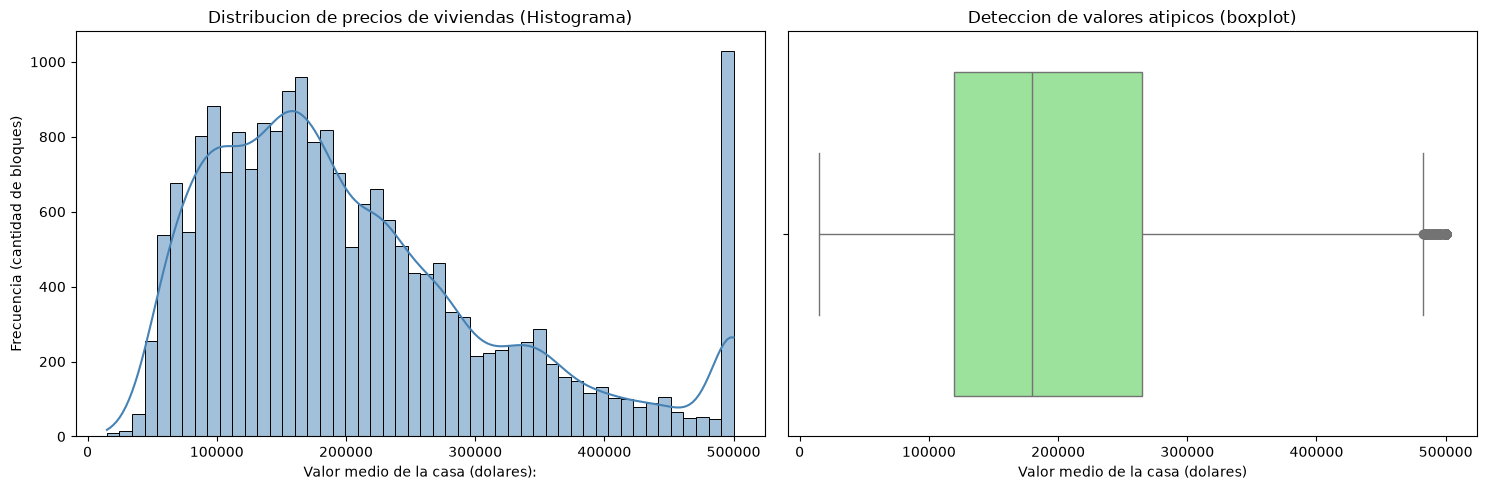

In [2]:
#analisis univariado

#preparacion de matplotlib
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

#pintar el histograma en el espacio izquierdo
sns.histplot(data=df, x='median_house_value', bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribucion de precios de viviendas (Histograma)')
axes[0].set_xlabel('Valor medio de la casa (dolares):')
axes[0].set_ylabel('Frecuencia (cantidad de bloques)')

#pintar el boxplot en el espacio derecho
sns.boxplot(data=df, x='median_house_value', ax=axes[1], color='lightgreen')
axes[1].set_title('Deteccion de valores atipicos (boxplot)')
axes[1].set_xlabel('Valor medio de la casa (dolares)')

#ajustar y mostrar
plt.tight_layout()
plt.show()

## Análisis Univariado: El Poder Adquisitivo (Ingresos)
Analisis visual de la columna `median_income` para determinar la distribución de la riqueza en los bloques censales.

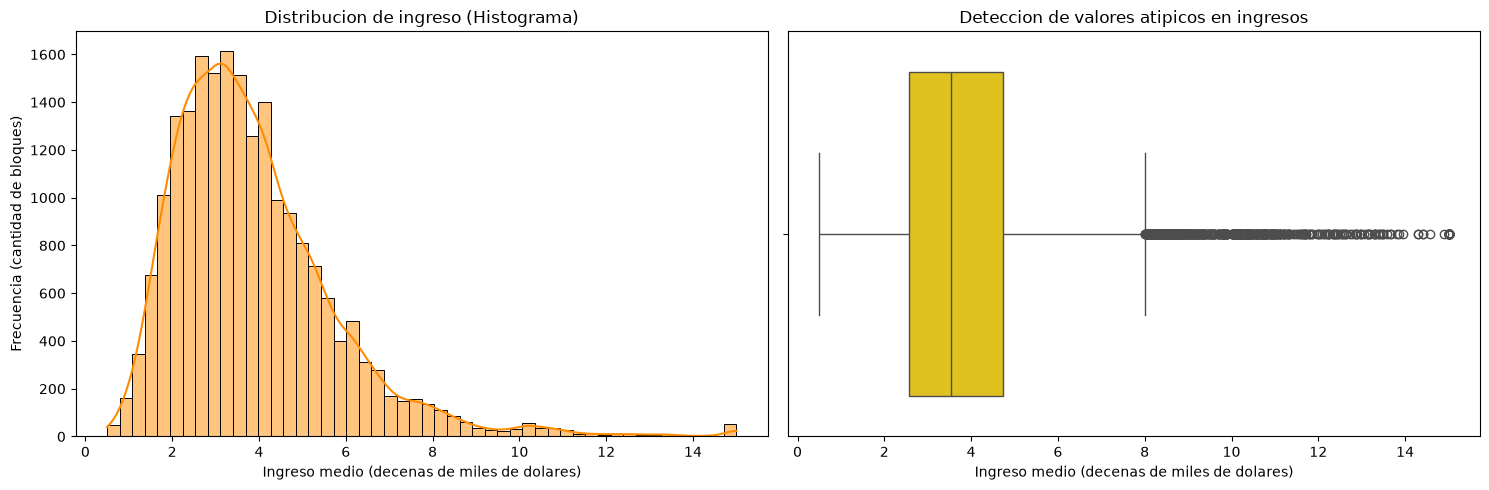

In [3]:
#estructura en matplot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

#histograma de ingresos
sns.histplot(data=df, x='median_income', bins=50, kde=True, ax=axes[0], color='darkorange')
axes[0].set_title('Distribucion de ingreso (Histograma)')
axes[0].set_xlabel('Ingreso medio (decenas de miles de dolares)')
axes[0].set_ylabel('Frecuencia (cantidad de bloques)')

#botplot de ingresos (deteccion matematica de anomalias)
sns.boxplot(data=df, x='median_income', ax=axes[1], color='gold')
axes[1].set_title('Deteccion de valores atipicos en ingresos')
axes[1].set_xlabel('Ingreso medio (decenas de miles de dolares)')

plt.tight_layout()
plt.show()

## Analisis Bivariado: Ingresos vs Precios
Evaluación de la correlación lineal entre el poder adquisitivo del bloque censal y el valor de las propiedades.

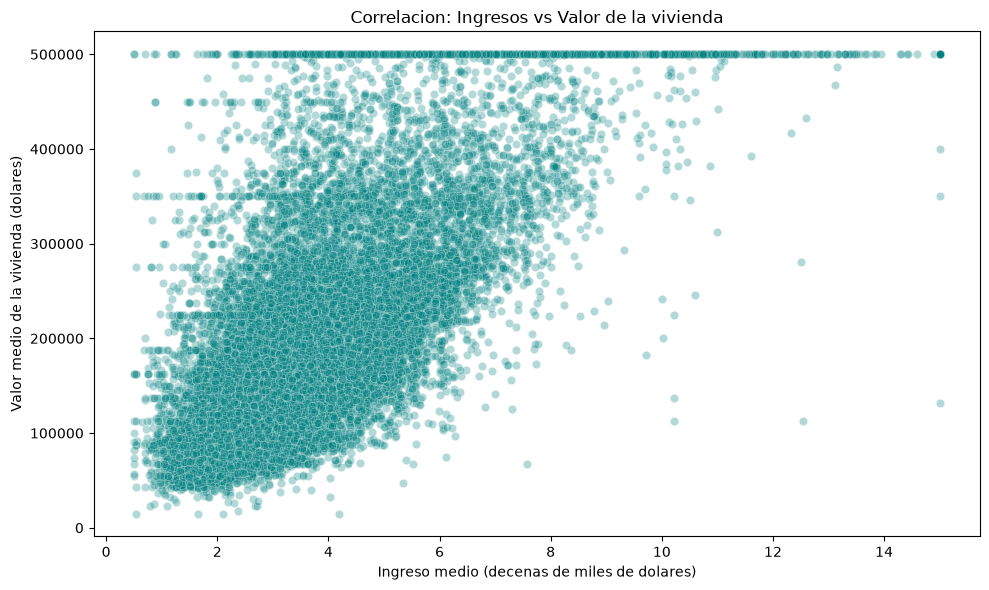

In [4]:
#analisis bivariado
plt.figure(figsize=(10, 6))

#dibujar la dispersion de puntos con transparencia (alpha) para ver la densidad
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.3, color='teal')

plt.title('Correlacion: Ingresos vs Valor de la vivienda')
plt.xlabel('Ingreso medio (decenas de miles de dolares)')
plt.ylabel('Valor medio de la vivienda (dolares)')

plt.tight_layout()
plt.show()

## Verificación de Techos Artificiales
Uso del filtrado de pandas para cuantificar la densidad de registros en el limite superior de `median_income`, `median_house_value` y `housing_median_age`

In [20]:
#MEDIAN_INCOME

#encontrar el valor matematico mas alto de la columna median_income
ingreso_max = df['median_income'].max()

#aislar/filtrar filas que tengan exactamente ese valor
bloques_tope_ingresos = df[df['median_income'] == ingreso_max]

#contar cuantos son
cantidad_bloques_ingreso = len(bloques_tope_ingresos)

#calcular que porcentaje del total representa
porcentaje_ingreso_tope = (cantidad_bloques_ingreso/len(df)) * 100

print('Reporte de posible anomalia (median_income)')
print(f'Valor maximo registrado: {ingreso_max}')
print(f'Cantidad de bloques con ese valor: {cantidad_bloques_ingreso}')
print(f'Porcentaje del dataset: {porcentaje_ingreso_tope:.2f}%')


Reporte de posible anomalia (median_income)
Valor maximo registrado: 15.0001
Cantidad de bloques con ese valor: 49
Porcentaje del dataset: 0.24%


In [19]:
#MEDIAN_HOUSE_VALUE
precio_max = df['median_house_value'].max()
bloques_tope_precio = df[df['median_house_value'] == precio_max]
porcentaje_precio_tope = (len(bloques_tope_precio) / len(df)) * 100

print('Reporte de posible anomalia (median_house_value)')
print(f'Valor maximo registrado: {precio_max}')
print(f'Cantidad de bloques con ese valor: {len(bloques_tope_precio)}')
print(f'Porcentaje del dataset: {porcentaje_precio_tope:.2f}%')

Reporte de posible anomalia (median_house_value)
Valor maximo registrado: 500001.0
Cantidad de bloques con ese valor: 965
Porcentaje del dataset: 4.68%


In [21]:
#HOUSING_MEDIAN_AGE
edad_max = df['housing_median_age'].max()
bloques_tope_edad = df[df['housing_median_age'] == edad_max]
porcentaje_edad_tope = (len(bloques_tope_edad) / len(df)) * 100

print('Reporte de posible anomalia (housing_median_age)')
print(f'Valor maximo registrado: {edad_max}')
print(f'Cantidad de bloques con ese valor: {len(bloques_tope_edad)}')
print(f'Porcentaje del dataset: {porcentaje_edad_tope:.2f}%')

Reporte de posible anomalia (housing_median_age)
Valor maximo registrado: 52.0
Cantidad de bloques con ese valor: 1273
Porcentaje del dataset: 6.17%


## Analisis de Datos Faltantes
Aislamiento y analisis de los registros con valores nulos en la columna `total_bedrooms`.

In [6]:
#crear dataframe con los valores nulos
filas_rotas = df[df['total_bedrooms'].isnull()]
porcentaje_nulos = (len(filas_rotas)/len(df)) * 100
print(f"Total de filas con nulos aisladas: {len(filas_rotas)}")
print(f"Porcentaje de filas con nulos: {porcentaje_nulos:.2f}%")
print("\nVista previa de las primeras 10 filas con valor nulo")
display(filas_rotas.head(10))



Total de filas con nulos aisladas: 207
Porcentaje de filas con nulos: 1.00%

Vista previa de las primeras 10 filas con valor nulo


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
738,-122.14,37.67,37.0,3342.0,NaN,1635.0,557.0,4.7933,186900.0,NEAR BAY
1097,-121.77,39.66,20.0,3759.0,NaN,1705.0,600.0,4.7120,158600.0,INLAND
1350,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,143100.0,INLAND
1456,-121.98,37.96,22.0,2987.0,NaN,1420.0,540.0,3.6500,204100.0,INLAND
1493,-122.01,37.94,23.0,3741.0,NaN,1339.0,499.0,6.7061,322300.0,NEAR BAY


## Curacion de Valores Nulos
Curación de la columna `total_bedrooms` mediante la imputación de la mediana espacial para preservar la varianza del dataset sin eliminar registros.

In [7]:
#curacion de datos
nota = '''
Si bien rellenar con la mediana sigue siendo un sesgo matematico minusculo, cuando representa menos del 3% o el 5%
es casi insignificante, en este caso el porcentaje de valores nulos representa el 1%
'''
#calcular la mediana exacta de los dormitorios
mediana_dormitorios = df['total_bedrooms'].median()
print(f"Mediana calculada para curacion: {mediana_dormitorios}")

#inyectar este valor unicamente en los huecos nulos NaN
df['total_bedrooms'] = df['total_bedrooms'].fillna(mediana_dormitorios) #con esto se rellena los valore NaN :3

#confirmacion
nulos_restantes = df['total_bedrooms'].isnull().sum()
assert nulos_restantes == 0
print(f"Columna limpiada. Nulos restantes en la columna: {nulos_restantes}")
print(nota)


Mediana calculada para curacion: 435.0
Columna limpiada. Nulos restantes en la columna: 0

Si bien rellenar con la mediana sigue siendo un sesgo matematico minusculo, cuando representa menos del 3% o el 5%
es casi insignificante, en este caso el porcentaje de valores nulos representa el 1%



## Sintesis de Variables Estructurales (Ratios)
Creación de proporciones espaciales y demográficas para dotar al algoritmo de contexto sobre el nivel de hacinamiento y calidad arquitectónica.

In [8]:
#habitaciones por hogar, metrica lujo/amplitud
df['rooms_per_household'] = df['total_rooms'] / df['households']

#dormitorios por habitacion, metrica de utilidad arquitectonica
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

#personas por hogar, metrica de densidad
df['population_per_household'] = df['population'] / df['households']

#visualizacion de nuevos datos
print('Vista previa de nuevos datos')
display(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

Vista previa de nuevos datos


,rooms_per_household,bedrooms_per_room,population_per_household
0,6.984127,0.146591,2.555556
1,6.238137,0.155797,2.109842
2,8.288136,0.129516,2.802260
3,5.817352,0.184458,2.547945
4,6.281853,0.172096,2.181467


## Exploración Visual de Relaciones (Pairplot)
Inspección simultánea de las relaciones entre variables clave y la variable objetivo.
Cada celda muestra la dispersión entre dos variables, la diagonal muestra la densidad
individual de cada una. Complementa el heatmap de Pearson con la forma visual de cada relación.

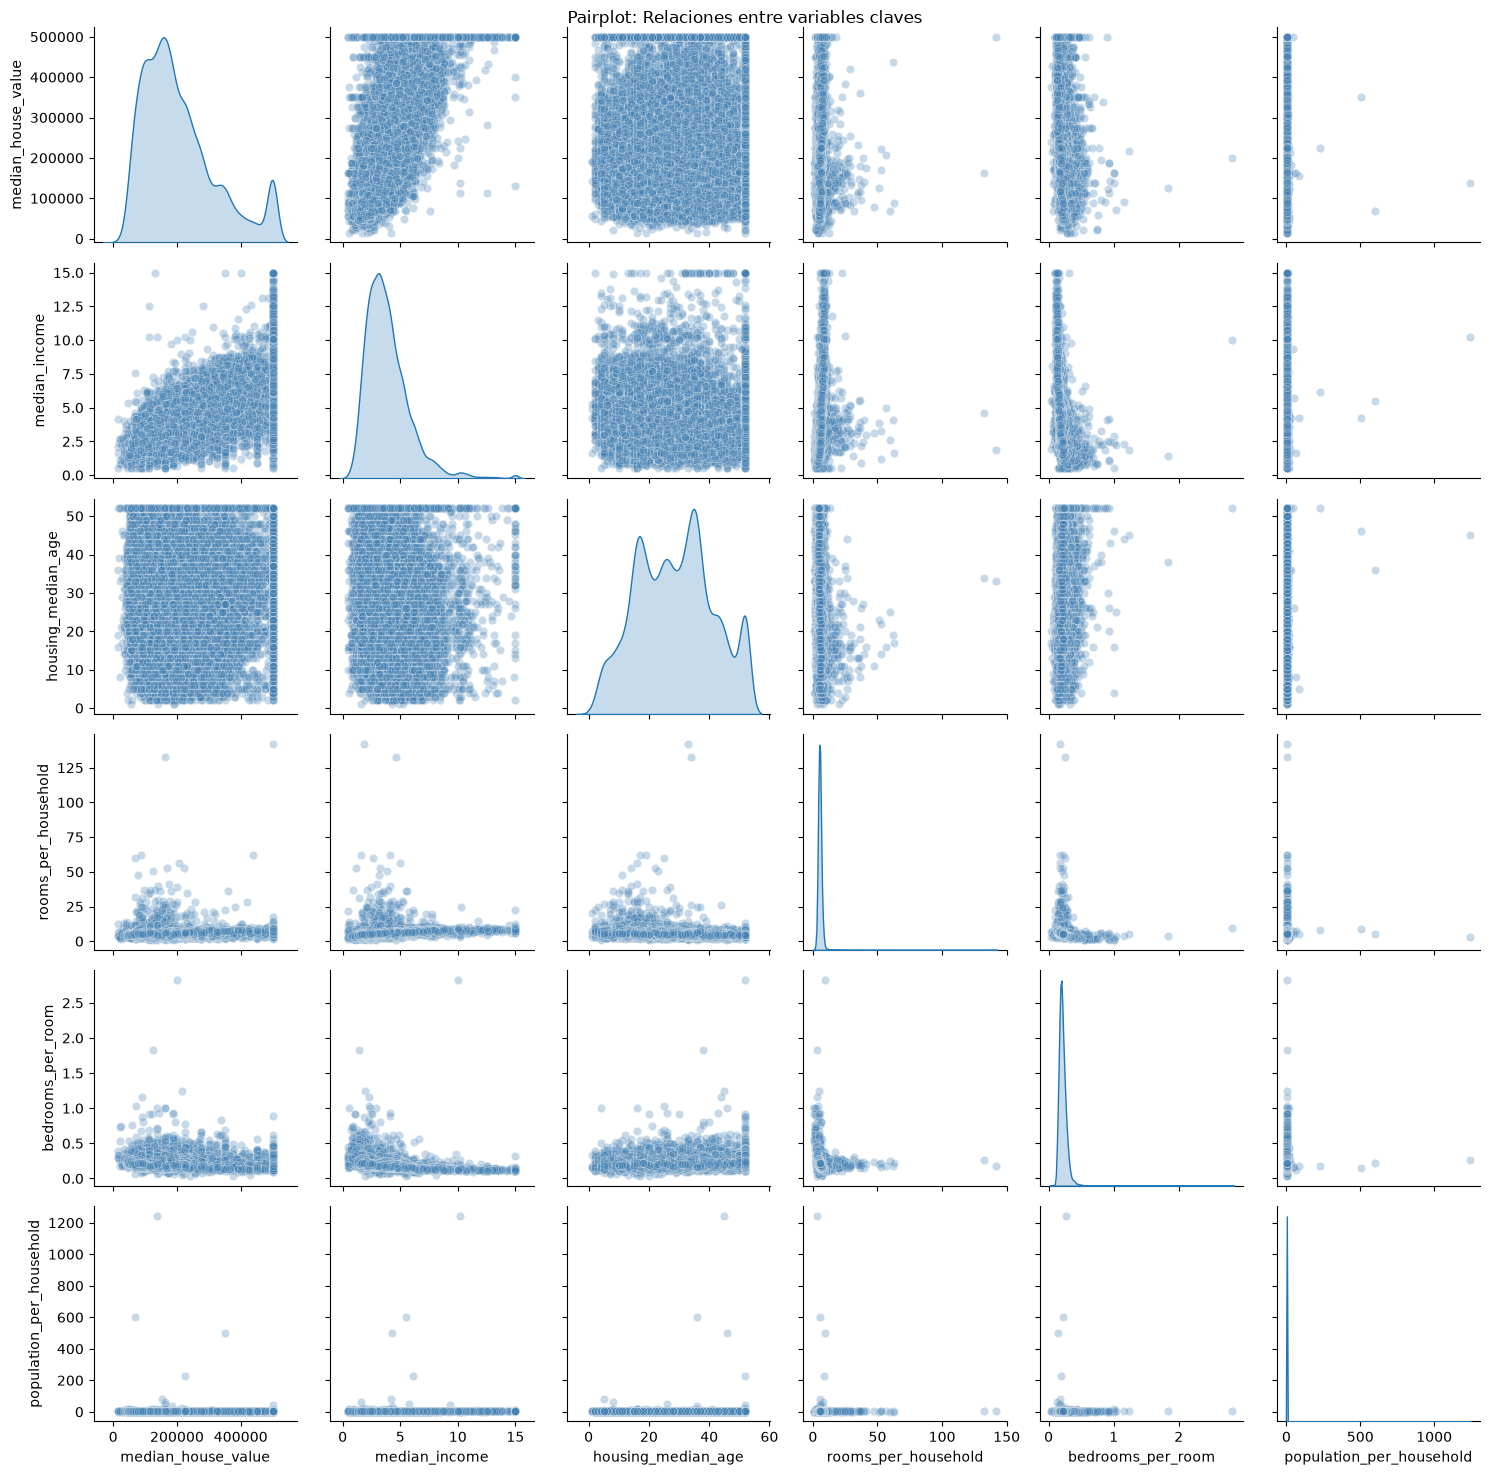

In [13]:
#Pairplot, relaciones entre variables
columnas_pairplot = [
    'median_house_value',
    'median_income',
    'housing_median_age',
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household'
]

sns.pairplot(
    df[columnas_pairplot],
    diag_kind='kde', #distrubucion de la diagonal
    plot_kws={'alpha': 0.3, 'color': 'steelblue'}, #transparencia para ver la densidad
)

plt.suptitle('Pairplot: Relaciones entre variables claves')
plt.tight_layout()
plt.show()

## Analisis de Correlación Multivariada (Heatmap)
Evaluación de la fuerza gravitacional matemática (Pearson) entre todas las variables numéricas y la variable objetivo `median_house_value`.

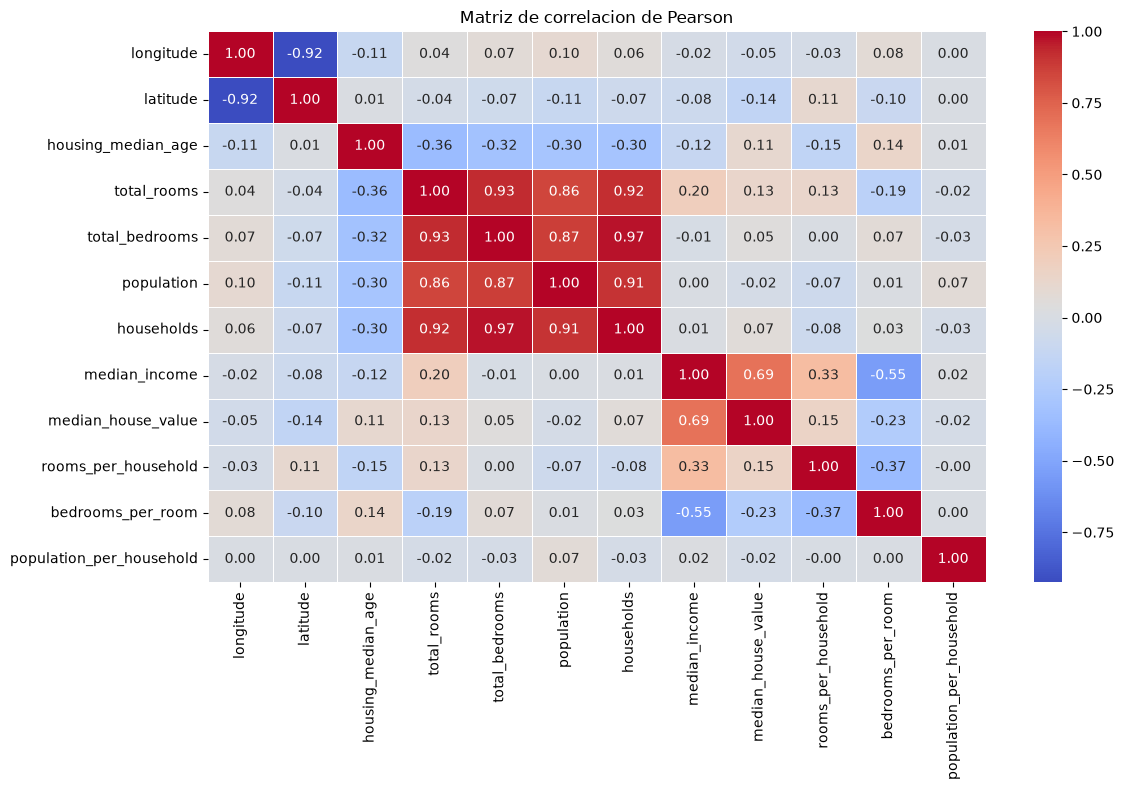

In [9]:
#mapa de correlacion de Pearson

#filtrar solo la columna numerica
columnas_numericas = df.select_dtypes(include=[np.number])

#calcular la matriz matematica de correlacion
matriz_correlacion = columnas_numericas.corr()

#dibujar mapa de calor
plt.figure(figsize=(12, 8))

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Matriz de correlacion de Pearson')
plt.tight_layout()
plt.show()


### Analisis Segmentado: Impacto de la Ubicación Geográfica
Evaluación de la distribución del valor de las propiedades segmentado por la variable categórica de proximidad al océano, aislando la influencia del entorno físico sobre el precio.

C:\Users\espin\AppData\Local\Temp\ipykernel_17864\1263389735.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='Set2')


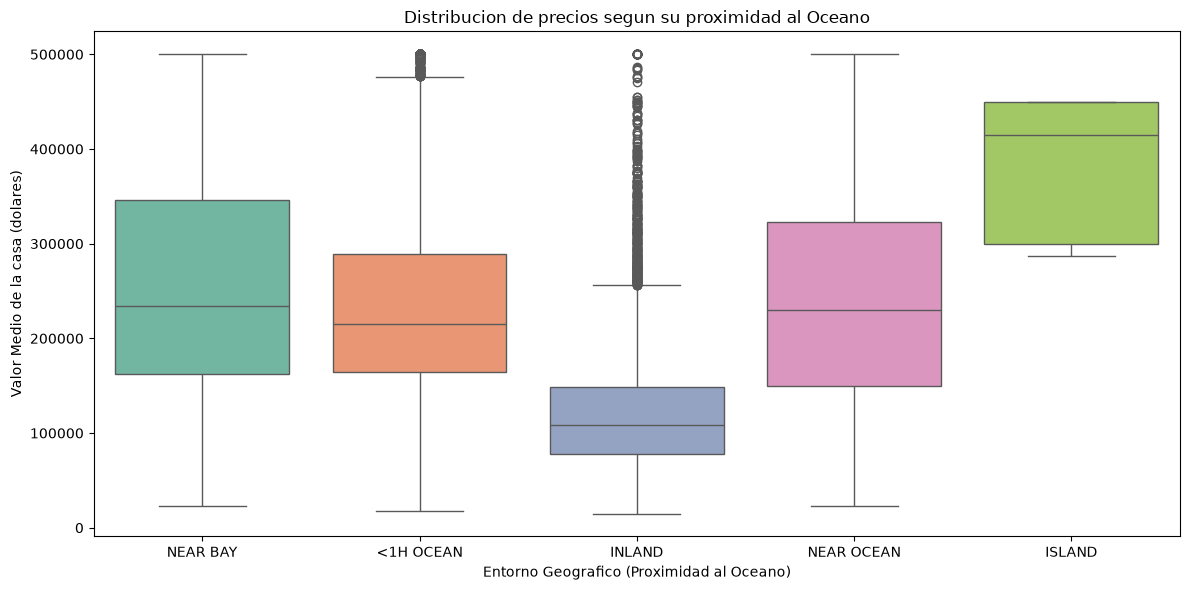

In [10]:
plt.figure(figsize=(12, 6))

#dibujar un boxplot
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', palette='Set2')

plt.title('Distribucion de precios segun su proximidad al Oceano')
plt.xlabel('Entorno Geografico (Proximidad al Oceano)')
plt.ylabel('Valor Medio de la casa (dolares)')

plt.tight_layout()
plt.show()